## dataloader

In [41]:
# ── Method 2: Using the convenience function ────────────────────────────────
import numpy as np

splits_alt, features = load_dataset()

print("\n" + "=" * 60)
print("ALTERNATIVE: Using load_dataset() convenience function")
print("=" * 60)
print(f"Features: {features}")
print(f"Train rows: {len(splits_alt['train'])}")
print(f"Val rows: {len(splits_alt['val'])}")
print(f"Test rows: {len(splits_alt['test'])}")

# ── Method 3: Get all splits as numpy arrays at once ────────────────────────
all_splits_arrays = loader.get_all_splits(return_arrays=True)

print("\n" + "=" * 60)
print("NUMPY ARRAYS: Ready for model training")
print("=" * 60)
for split_name, (X, y) in all_splits_arrays.items():
    print(f"{split_name}: X {X.shape} (float32), y {y.shape} (int64)")
    print(f"  -> y classes: {np.unique(y)}, class ratio: {np.bincount(y)}")

INFO:dataloader:Loaded dataset: 2541 rows, 31 columns
INFO:dataloader:Found 24 unique subjects
INFO:dataloader:Splitting 24 subjects into train/val/test...
INFO:dataloader:train: 2015 rows (79.3%), 18 subjects (75.0%), labels: {0: 1283, 1: 732}
INFO:dataloader:val: 48 rows (1.9%), 3 subjects (12.5%), labels: {0: 29, 1: 19}
INFO:dataloader:test: 478 rows (18.8%), 3 subjects (12.5%), labels: {0: 304, 1: 174}



ALTERNATIVE: Using load_dataset() convenience function
Features: ['sdnn_znorm', 'cv_rr_znorm', 'rmssd_znorm', 'pnn50_znorm']
Train rows: 2015
Val rows: 48
Test rows: 478

NUMPY ARRAYS: Ready for model training
train: X (2015, 4) (float32), y (2015,) (int64)
  -> y classes: [0 1], class ratio: [1283  732]
val: X (48, 4) (float32), y (48,) (int64)
  -> y classes: [0 1], class ratio: [29 19]
test: X (478, 4) (float32), y (478,) (int64)
  -> y classes: [0 1], class ratio: [304 174]


## Bayesian Hyperparameter Optimization

In [44]:
# Run XGBoost Bayesian Hyperparameter Optimization
# Using fixed split mode with 50 trials (production would use 100+)
print("Starting XGBoost Bayesian Hyperparameter Optimization...")
print("This may take 5-10 minutes depending on system")
print("=" * 60)

result_xgb = tune_xgboost(loader, n_trials=50, loso=False, verbose=True)
best_xgb_params = result_xgb["best_params"]
best_xgb_value = result_xgb["best_value"]

print("\n" + "=" * 60)
print("XGBoost Optimization Complete!")
print(f"Best F1 Score: {best_xgb_value:.4f}")
print("\nBest Parameters:")
for key, value in best_xgb_params.items():
    print(f"  {key}: {value}")

[I 2026-05-30 10:32:13,568] A new study created in memory with name: no-name-7c08e308-a798-4d64-93f1-3c04f1e3a7f5


INFO:bayesian_hpo:Starting XGBoost hyperparameter tuning (50 trials, fixed split)...


Starting XGBoost Bayesian Hyperparameter Optimization...
This may take 5-10 minutes depending on system


Best trial: 1. Best value: 0.970752:   4%|▍         | 2/50 [00:00<00:08,  5.59it/s]

[I 2026-05-30 10:32:13,819] Trial 0 finished with value: 0.9566239316239316 and parameters: {'n_estimators': 218, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_lambda': 8.661761457749352, 'reg_alpha': 6.011150117432088}. Best is trial 0 with value: 0.9566239316239316.
[I 2026-05-30 10:32:13,956] Trial 1 finished with value: 0.9707520891364902 and parameters: {'n_estimators': 369, 'max_depth': 3, 'learning_rate': 0.2526878207508456, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'min_child_weight': 2, 'gamma': 0.9170225492671691, 'reg_lambda': 3.0424224295953772, 'reg_alpha': 5.247564316322379}. Best is trial 1 with value: 0.9707520891364902.


...

[I 2026-05-30 10:32:25,746] Trial 47 finished with value: 0.9512123004139562 and parameters: {'n_estimators': 339, 'max_depth': 8, 'learning_rate': 0.0614944367347601, 'subsample': 0.7385925382637037, 'colsample_bytree': 0.8978112361474877, 'min_child_weight': 5, 'gamma': 3.273293263689735, 'reg_lambda': 2.771225534039237, 'reg_alpha': 3.1370318283018754}. Best is trial 33 with value: 0.9817927170868348.


INFO:bayesian_hpo:Trial 48: F1=0.9648 (std=0.0095)
Best trial: 33. Best value: 0.981793:  98%|█████████▊| 49/50 [00:12<00:00,  2.15it/s]

[I 2026-05-30 10:32:26,121] Trial 48 finished with value: 0.9648331184644034 and parameters: {'n_estimators': 184, 'max_depth': 10, 'learning_rate': 0.04319206958196401, 'subsample': 0.6185152360467505, 'colsample_bytree': 0.8330046440111712, 'min_child_weight': 6, 'gamma': 4.126632401033404, 'reg_lambda': 1.363354560672414, 'reg_alpha': 2.3299628633296408}. Best is trial 33 with value: 0.9817927170868348.


INFO:bayesian_hpo:Trial 49: F1=0.9622 (std=0.0122)
Best trial: 33. Best value: 0.981793: 100%|██████████| 50/50 [00:13<00:00,  3.82it/s]
INFO:bayesian_hpo:XGBoost tuning complete. Best F1=0.9818
INFO:bayesian_hpo:Best hyperparameters: {'n_estimators': 256, 'max_depth': 9, 'learning_rate': 0.04525097277844526, 'subsample': 0.768556687272776, 'colsample_bytree': 0.8062003203775366, 'min_child_weight': 4, 'gamma': 1.5387458561375038, 'reg_lambda': 1.8228848433838216, 'reg_alpha': 1.1095671228917217}


[I 2026-05-30 10:32:26,672] Trial 49 finished with value: 0.9621794871794871 and parameters: {'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.033153984873997185, 'subsample': 0.809322363489872, 'colsample_bytree': 0.9750138729140305, 'min_child_weight': 9, 'gamma': 1.7497446790744036, 'reg_lambda': 0.059833328635962385, 'reg_alpha': 1.2290074443588541}. Best is trial 33 with value: 0.9817927170868348.

XGBoost Optimization Complete!
Best F1 Score: 0.9818

Best Parameters:
  n_estimators: 256
  max_depth: 9
  learning_rate: 0.04525097277844526
  subsample: 0.768556687272776
  colsample_bytree: 0.8062003203775366
  min_child_weight: 4
  gamma: 1.5387458561375038
  reg_lambda: 1.8228848433838216
  reg_alpha: 1.1095671228917217


In [46]:
# Save best parameters to a documentation file
import json
from datetime import datetime

# Prepare results dictionary
hpo_results = {
    "timestamp": datetime.now().isoformat(),
    "xgboost": {"best_f1_score": float(best_xgb_value), "parameters": best_xgb_params},
    "catboost": {"best_f1_score": float(best_cat_value), "parameters": best_cat_params},
}

# Save to JSON file
results_file = "../outputs/hpo_best_parameters.json"
with open(results_file, "w") as f:
    json.dump(hpo_results, f, indent=2)

print(f"✓ Best parameters saved to: {results_file}")
print("\nSummary:")
print(f"  XGBoost F1: {best_xgb_value:.4f}")
print(f"  CatBoost F1: {best_cat_value:.4f}")
print(f"  Best Model: {'XGBoost' if best_xgb_value >= best_cat_value else 'CatBoost'}")
print(f"              (F1: {max(best_xgb_value, best_cat_value):.4f})")

✓ Best parameters saved to: ../outputs/hpo_best_parameters.json

Summary:
  XGBoost F1: 0.9818
  CatBoost F1: 0.9829
  Best Model: CatBoost
              (F1: 0.9829)


In [ ]:
# Train and evaluate XGBoost with best hyperparameters
import xgboost as xgb
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

print("Training XGBoost with best hyperparameters...")
print("=" * 60)

# Get data
splits = splits_alt  # Using normalized data
X_train = splits["train"][loader.feature_cols].values
y_train = splits["train"][loader.target_col].values
X_val = splits["val"][loader.feature_cols].values
y_val = splits["val"][loader.target_col].values
X_test = splits["test"][loader.feature_cols].values
y_test = splits["test"][loader.target_col].values

# Build XGBoost model with best parameters
scale_pos_weight = (y_train == 0).sum() / ((y_train == 1).sum() + 1e-6)
xgb_model_best = xgb.XGBClassifier(
    **best_xgb_params, scale_pos_weight=scale_pos_weight, random_state=42, verbosity=0
)

# Train
xgb_model_best.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# Predict
y_pred_xgb = xgb_model_best.predict(X_test)
y_proba_xgb = xgb_model_best.predict_proba(X_test)[:, 1]

# Evaluate
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_proba_xgb)
xgb_prauc = average_precision_score(y_test, y_proba_xgb)

print("\nXGBoost Test Metrics:")
print(f"  F1 Score:     {xgb_f1:.4f}")
print(f"  Precision:    {xgb_precision:.4f}")
print(f"  Recall:       {xgb_recall:.4f}")
print(f"  ROC-AUC:      {xgb_auc:.4f}")
print(f"  PR-AUC:       {xgb_prauc:.4f}")

Training XGBoost with best hyperparameters...

XGBoost Test Metrics:
  F1 Score:     0.9636
  Precision:    0.9399
  Recall:       0.9885
  ROC-AUC:      0.9945
  PR-AUC:       0.9897


In [49]:
# Compare results and save comparison
import pandas as pd

print("\n" + "=" * 60)
print("HYPERPARAMETER TUNING RESULTS COMPARISON")
print("=" * 60)

# Create comparison dataframe
comparison_df = pd.DataFrame(
    {
        "XGBoost": [xgb_f1, xgb_precision, xgb_recall, xgb_auc, xgb_prauc],
        "CatBoost": [cat_f1, cat_precision, cat_recall, cat_auc, cat_prauc],
    },
    index=["F1 Score", "Precision", "Recall", "ROC-AUC", "PR-AUC"],
)

print("\nTest Set Performance:")
print(comparison_df.round(4))

# Determine winner
winner = "XGBoost" if xgb_f1 >= cat_f1 else "CatBoost"
print(f"\n🏆 Best Model: {winner} (F1: {max(xgb_f1, cat_f1):.4f})")

# Save comparison to file
comparison_file = "../outputs/hpo_results_comparison.csv"
comparison_df.to_csv(comparison_file)
print(f"✓ Comparison saved to: {comparison_file}")

# Create detailed report
report = {
    "timestamp": datetime.now().isoformat(),
    "hpo_trials": 50,
    "hpo_mode": "fixed_split",
    "xgboost": {
        "hpo_best_f1": float(best_xgb_value),
        "test_metrics": {
            "f1_score": float(xgb_f1),
            "precision": float(xgb_precision),
            "recall": float(xgb_recall),
            "roc_auc": float(xgb_auc),
            "pr_auc": float(xgb_prauc),
        },
        "best_parameters": best_xgb_params,
    },
    "catboost": {
        "hpo_best_f1": float(best_cat_value),
        "test_metrics": {
            "f1_score": float(cat_f1),
            "precision": float(cat_precision),
            "recall": float(cat_recall),
            "roc_auc": float(cat_auc),
            "pr_auc": float(cat_prauc),
        },
        "best_parameters": best_cat_params,
    },
    "winner": winner,
}

# Save detailed report
report_file = "../outputs/hpo_detailed_report.json"
with open(report_file, "w") as f:
    json.dump(report, f, indent=2)

print(f"✓ Detailed report saved to: {report_file}")


HYPERPARAMETER TUNING RESULTS COMPARISON

Test Set Performance:
           XGBoost  CatBoost
F1 Score    0.9636    0.9657
Precision   0.9399    0.9602
Recall      0.9885    0.9713
ROC-AUC     0.9945    0.9928
PR-AUC      0.9897    0.9870

🏆 Best Model: CatBoost (F1: 0.9657)
✓ Comparison saved to: ../outputs/hpo_results_comparison.csv
✓ Detailed report saved to: ../outputs/hpo_detailed_report.json


In [50]:
%matplotlib inline
import matplotlib.pyplot as plt  # noqa: F401  # prime inline backend before train_classifiers
import pandas as pd
from IPython.display import Image, display
from sklearn.metrics import precision_recall_curve, roc_curve

from train_classifiers import (
    MODEL_NAMES,
    PLOTS_DIR,
    _format_comparison_fixed,
    _format_comparison_loso,
    _run_loso,
    _train_and_eval_fixed,
    plot_feature_importance,
    plot_pr_curves,
    plot_roc_curves,
)

In [51]:
# Reuse the `loader` already prepared in the dataloader cells above
fixed_results = _train_and_eval_fixed(loader)
print(_format_comparison_fixed(fixed_results))

INFO:train_classifiers:Fixed split sizes: train=2015  val=48  test=478
INFO:train_classifiers:Training XGBoost (fixed split)...


INFO:train_classifiers:XGBoost / val | prec=1.0000  rec=1.0000  f1=1.0000  roc_auc=1.0000  pr_auc=1.0000
INFO:train_classifiers:XGBoost / test | prec=0.9274  rec=0.9540  f1=0.9405  roc_auc=0.9894  pr_auc=0.9785
INFO:train_classifiers:Training CatBoost (fixed split)...
INFO:train_classifiers:CatBoost / val | prec=0.9500  rec=1.0000  f1=0.9744  roc_auc=1.0000  pr_auc=1.0000
INFO:train_classifiers:CatBoost / test | prec=0.9548  rec=0.9713  f1=0.9630  roc_auc=0.9930  pr_auc=0.9871


CLASSIFIER COMPARISON (FIXED SPLIT)

  Model      Split     N   Prec    Rec     F1  ROC-AUC  PR-AUC
--------------------------------------------------------------------------------
  XGBoost    val      48 1.0000 1.0000 1.0000   1.0000  1.0000
  XGBoost    test    478 0.9274 0.9540 0.9405   0.9894  0.9785
  CatBoost   val      48 0.9500 1.0000 0.9744   1.0000  1.0000
  CatBoost   test    478 0.9548 0.9713 0.9630   0.9930  0.9871


INFO:train_classifiers:Saved -> c:\Users\moris\OneDrive\Documents\hackathon_blr\drowsiness-detection\notebooks\..\outputs\classifier_plots\fig_feature_importance.png


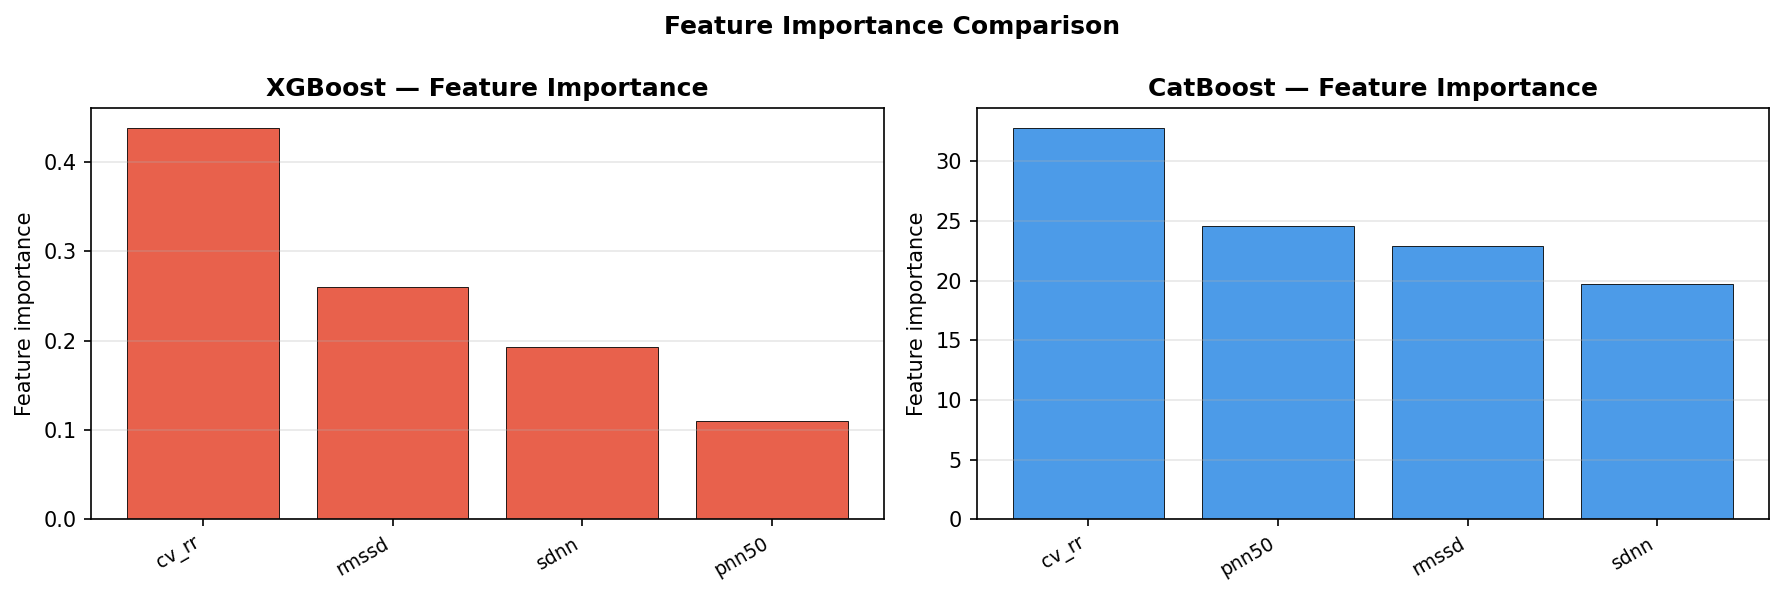

In [53]:
# Feature importance for both fitted models
fitted_models_fixed = {name: fixed_results[name]["model"] for name in MODEL_NAMES}
plot_feature_importance(fitted_models_fixed, loader.feature_cols)
display(Image(str(PLOTS_DIR / "fig_feature_importance.png")))

In [54]:
# `loader.df` is available after prepare() — no extra load_data() call needed
loso_results = _run_loso(loader)

INFO:dataloader:Creating LOSO folds with 24 subjects...
INFO:dataloader:Fold  1/24: test_subject=ddd_01M, train_samples=2307, test_samples=234
INFO:dataloader:Fold  2/24: test_subject=ddd_02F, train_samples=2305, test_samples=236
INFO:dataloader:Fold  3/24: test_subject=ddd_03F, train_samples=2306, test_samples=235
INFO:dataloader:Fold  4/24: test_subject=ddd_04M, train_samples=2314, test_samples=227
INFO:dataloader:Fold  5/24: test_subject=ddd_05M, train_samples=2309, test_samples=232
INFO:dataloader:Fold  6/24: test_subject=ddd_06M, train_samples=2307, test_samples=234
INFO:dataloader:Fold  7/24: test_subject=ddd_07F, train_samples=2307, test_samples=234
INFO:dataloader:Fold  8/24: test_subject=ddd_08M, train_samples=2309, test_samples=232
INFO:dataloader:Fold  9/24: test_subject=ddd_09M, train_samples=2309, test_samples=232
INFO:dataloader:Fold 10/24: test_subject=ddd_10M, train_samples=2309, test_samples=232
INFO:dataloader:Fold 11/24: test_subject=drozy_s01, train_samples=2523, te

INFO:train_classifiers:Saved -> c:\Users\moris\OneDrive\Documents\hackathon_blr\drowsiness-detection\notebooks\..\outputs\classifier_plots\fig_roc_curves_loso.png
INFO:train_classifiers:Saved -> c:\Users\moris\OneDrive\Documents\hackathon_blr\drowsiness-detection\notebooks\..\outputs\classifier_plots\fig_pr_curves_loso.png


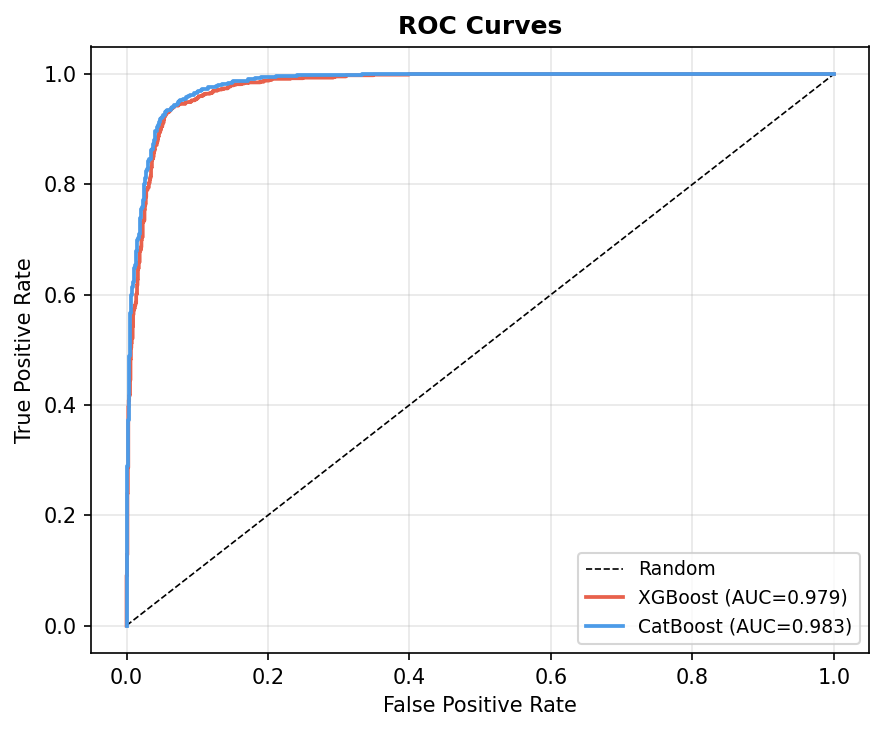

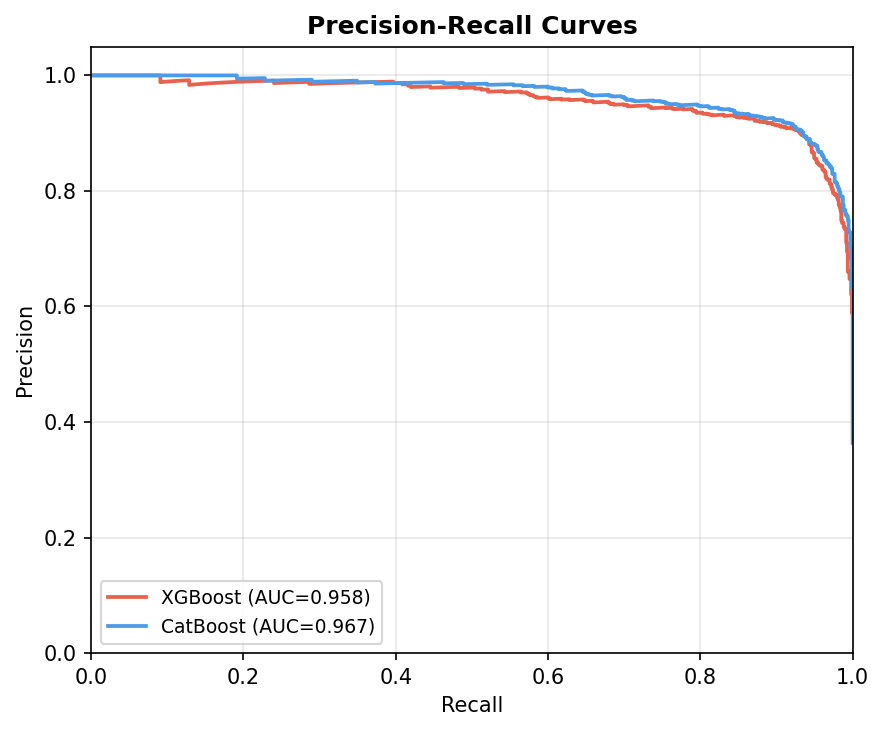

In [56]:
# LOSO pooled ROC + PR curves
roc_data_loso = {}
pr_data_loso = {}
for name in MODEL_NAMES:
    r = loso_results[name]
    fpr, tpr, _ = roc_curve(r["y_true"], r["y_proba"])
    prec, rec, _ = precision_recall_curve(r["y_true"], r["y_proba"])
    roc_data_loso[name] = (fpr, tpr, r["overall"]["roc_auc"])
    pr_data_loso[name] = (prec, rec, r["overall"]["pr_auc"])

plot_roc_curves(roc_data_loso, suffix="_loso")
plot_pr_curves(pr_data_loso, suffix="_loso")
display(Image(str(PLOTS_DIR / "fig_roc_curves_loso.png")))
display(Image(str(PLOTS_DIR / "fig_pr_curves_loso.png")))

In [57]:
# Identify the better-performing model on each evaluation protocol
print("=== Fixed Split — Test Set ===")
best_fixed = max(MODEL_NAMES, key=lambda n: fixed_results[n]["test"]["f1"])
for name in MODEL_NAMES:
    m = fixed_results[name]["test"]
    print(
        f"  {name:10s}: Prec={m['precision']:.4f}  Rec={m['recall']:.4f}  "
        f"F1={m['f1']:.4f}  ROC-AUC={m['roc_auc']:.4f}  PR-AUC={m['pr_auc']:.4f}"
    )
print(f"\n  Best (F1): {best_fixed}")

print("\n=== LOSO-CV — Pooled (optimal threshold) ===")
best_loso = max(MODEL_NAMES, key=lambda n: loso_results[n]["overall"]["f1"])
for name in MODEL_NAMES:
    m = loso_results[name]["overall"]
    thr = loso_results[name]["opt_threshold"]
    print(
        f"  {name:10s}: Prec={m['precision']:.4f}  Rec={m['recall']:.4f}  "
        f"F1={m['f1']:.4f}  ROC-AUC={m['roc_auc']:.4f}  PR-AUC={m['pr_auc']:.4f}  "
        f"threshold={thr:.4f}"
    )
print(f"\n  Best (F1): {best_loso}")

=== Fixed Split — Test Set ===
  XGBoost   : Prec=0.9274  Rec=0.9540  F1=0.9405  ROC-AUC=0.9894  PR-AUC=0.9785
  CatBoost  : Prec=0.9548  Rec=0.9713  F1=0.9630  ROC-AUC=0.9930  PR-AUC=0.9871

  Best (F1): CatBoost

=== LOSO-CV — Pooled (optimal threshold) ===
  XGBoost   : Prec=0.9892  Rec=0.3968  F1=0.5664  ROC-AUC=0.9786  PR-AUC=0.9580  threshold=0.9991
  CatBoost  : Prec=0.9908  Rec=0.3492  F1=0.5164  ROC-AUC=0.9827  PR-AUC=0.9669  threshold=0.9954

  Best (F1): XGBoost


## Threshold Adjustment to Minimize False Positive Rate

In [77]:
import sys
sys.path.insert(0, "../src")
from threshold_utils import find_threshold_for_fpr
from sklearn.metrics import confusion_matrix

target_fpr = 0.05 # Allow max 5% false positive rate

print(f"Testing threshold adjustment for target FPR = {target_fpr:.2f}\n")

for model_name, model in [("XGBoost", xgb_model_best), ("CatBoost", cat_model_best)]:
    print(f"--- {model_name} ---")
    y_proba_test = model.predict_proba(X_test)[:, 1]
    
    new_threshold = find_threshold_for_fpr(y_test, y_proba_test, target_fpr)
    y_pred_new = (y_proba_test >= new_threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred_new)
    print(f"New Threshold: {new_threshold:.4f}")
    print(f"Confusion Matrix:\n{cm}\n")


Testing threshold adjustment for target FPR = 0.05

--- XGBoost ---
New Threshold: 0.4438
Confusion Matrix:
[[290  14]
 [  1 173]]

--- CatBoost ---
New Threshold: 0.3687
Confusion Matrix:
[[289  15]
 [  2 172]]

